# Data Exploration

## Patient Level MetaData
Cohort Exploration
APOE and PICALM genotypes

In [ ]:
import pandas as pd

In [58]:
# Download full cohort
full_cohort = pd.read_csv('../data/participant_metadata/participants.tsv', sep='\t')

# check of full cohort df
print(full_cohort.head(10))

  participant_id  second_phase  session_order APOE_rs429358 APOE_rs7412  \
0         sub-01             1            1.0           T/T         C/C   
1         sub-02             1            1.0           T/T         C/C   
2         sub-03             1            0.0           T/T         C/C   
3         sub-04             1            0.0           T/T         C/C   
4         sub-05             1            0.0           T/T         C/C   
5         sub-06             1            NaN           T/T         C/C   
6         sub-07             1            0.0           T/T         C/C   
7         sub-08             1            1.0           T/T         C/C   
8         sub-09             1            1.0           T/T         C/C   
9         sub-10             1            1.0           T/T         C/C   

  APOE_haplotype PICALM_rs3851179  age  sex  education  ... lymphocytes_%  \
0          e3/e3              A/A   59    0        3.0  ...          26.6   
1          e3/e3    

In [83]:
# subset full cohort to participants that have eeg/fmri 
participants = full_cohort[full_cohort["second_phase"] == 1].copy()

print(full_cohort.shape)
print(participants.shape) # 79 participants

(192, 87)
(79, 87)


## Overview of Cohort Demographic

In [84]:
# Age information
age_summary = participants["age"].agg(["mean", "std", "min", "median", "max"]).round(2)
print(f"Age summary for n={len(participants)} participants:")
display(age_summary)

Age summary for n=79 participants:


mean      55.30
std        3.12
min       50.00
median    56.00
max       63.00
Name: age, dtype: float64

In [85]:
# APOE e4 carriers

# Clean to remove space
participants["APOE_haplotype"] = participants["APOE_haplotype"].str.strip()

display(participants["APOE_haplotype"].value_counts(dropna=False))
 
participants["is_e4_carrier"] = participants["APOE_haplotype"].str.contains("e4", na=False)

carrier_counts = participants["is_e4_carrier"].value_counts()
carrier_pct = participants["is_e4_carrier"].mean() * 100

display(carrier_counts)
print(f"Percent e4 carriers: {carrier_pct:.1f}%")

APOE_haplotype
e3/e4    45
e3/e3    31
e4/e4     2
e2/e4     1
Name: count, dtype: int64

is_e4_carrier
True     48
False    31
Name: count, dtype: int64

Percent e4 carriers: 60.8%


In [86]:
# PICALM carriers
participants["PICALM_rs3851179"] = participants["PICALM_rs3851179"].str.strip()

participants["is_picalm_risk_carrier"] = participants["PICALM_rs3851179"].isin(["A/G", "G/G"])
display(participants["PICALM_rs3851179"].value_counts(dropna=False))

risk_pct = participants["PICALM_rs3851179"].isin(["G/A", "G/G"]).mean() * 100
print(f"PICALM risk-allele carriers (A/G or G/G): {risk_pct:.1f}%")

PICALM_rs3851179
G/A    46
G/G    22
A/A    11
Name: count, dtype: int64

PICALM risk-allele carriers (A/G or G/G): 86.1%


In [87]:
participants["education_label"] = participants["education"].replace({
    0: "primary education",
    1: "secondary education",
    2: "partial higher education", 
    3: "higher education"
})
display(participants["education_label"].value_counts(dropna=False))

participants["sex_label"] = participants["sex"].replace({
    0: "male",
    1: "female"
})
display(participants["sex_label"].value_counts(dropna=False))

participants["diabetes_label"] = participants["diabetes"].replace({
    0: "no",
    1: "yes"
})

display(participants["diabetes_label"].value_counts(dropna=False))

participants["hypertension_label"] = participants["hypertension"].replace({
    0: "no",
    1: "yes"
})
display(participants["hypertension_label"].value_counts(dropna=False))


participants["smoking_status_label"] = participants["smoking_status"].replace({
    0: "no",
    1: "yes",
    2: "in past"
})
display(participants["smoking_status_label"].value_counts(dropna=False))


education_label
higher education            60
NaN                          8
secondary education          8
partial higher education     3
Name: count, dtype: int64

sex_label
female    40
male      39
Name: count, dtype: int64

diabetes_label
no     78
yes     1
Name: count, dtype: int64

hypertension_label
no     59
yes    20
Name: count, dtype: int64

smoking_status_label
no         47
in past    22
yes         9
NaN         1
Name: count, dtype: int64

## Recoding APOE and PICALM alleles based on Risk Allele Dosage (0/1/2)

In [88]:
def allele_dosage(genotype, allele):
    if pd.isna(genotype):
        return pd.NA
    a1, a2 = genotype.strip().split("/")
    return int(a1 == allele) + int(a2 == allele)

participants["PICALM_risk_dosage"] = participants["PICALM_rs3851179"].apply(
    lambda x: allele_dosage(x, "G")
)
display(participants["PICALM_risk_dosage"].value_counts(dropna=False).sort_index())

PICALM_risk_dosage
0    11
1    46
2    22
Name: count, dtype: int64

In [89]:
participants["APOE_risk_dosage"] = participants["APOE_haplotype"].apply(
      lambda x: x.strip().split("/").count("e4") if pd.notna(x) else pd.NA
  )

display(participants["APOE_risk_dosage"].value_counts(dropna=False).sort_index())

APOE_risk_dosage
0    31
1    46
2     2
Name: count, dtype: int64

In [101]:

def make_dosage_table(df, dosage_col):
    grouped = df.groupby(dosage_col)
    rows = {}

    rows["N"] = grouped.size()
    rows["Age mean (SD)"] = grouped["age"].apply(lambda x: f"{x.mean():.2f} ({x.std():.2f})")

    def n_pct(x, condition):
        n = condition(x).sum()
        pct = condition(x).mean() * 100
        return f"{n} ({pct:.1f}%)"

    rows["Female, n (%)"] = grouped["sex_label"].apply(
        lambda x: n_pct(x, lambda s: s == "female")
    )
    rows["Diabetes, n (%)"] = grouped["diabetes_label"].apply(
        lambda x: n_pct(x, lambda s: s == "yes")
    )
    rows["Hypertension, n (%)"] = grouped["hypertension_label"].apply(
        lambda x: n_pct(x, lambda s: s == "yes")
    )
    rows["Higher education, n (%)"] = grouped["education_label"].apply(
        lambda x: n_pct(x, lambda s: s == "higher education")
    )

    table = pd.DataFrame(rows).T
    table = table.reindex(columns=[0, 1, 2])
    return table


In [102]:
apoe_table = make_dosage_table(participants, "APOE_risk_dosage")
display(apoe_table)

APOE_risk_dosage,0,1,2
N,31,46,2
Age mean (SD),54.77 (2.92),55.50 (3.10),59.00 (5.66)
"Female, n (%)",15 (48.4%),25 (54.3%),0 (0.0%)
"Diabetes, n (%)",0 (0.0%),1 (2.2%),0 (0.0%)
"Hypertension, n (%)",6 (19.4%),13 (28.3%),1 (50.0%)
"Higher education, n (%)",23 (74.2%),35 (76.1%),2 (100.0%)


In [103]:
picalm_table = make_dosage_table(participants, "PICALM_risk_dosage")
display(picalm_table)

PICALM_risk_dosage,0,1,2
N,11,46,22
Age mean (SD),54.73 (3.41),55.22 (3.00),55.77 (3.31)
"Female, n (%)",5 (45.5%),23 (50.0%),12 (54.5%)
"Diabetes, n (%)",0 (0.0%),0 (0.0%),1 (4.5%)
"Hypertension, n (%)",3 (27.3%),12 (26.1%),5 (22.7%)
"Higher education, n (%)",8 (72.7%),32 (69.6%),20 (90.9%)


In [106]:
overlap_table = pd.crosstab(
    participants["APOE_risk_dosage"],
    participants["PICALM_risk_dosage"],
    dropna=False
    ).reindex(index=[0, 1, 2], columns=[0, 1, 2])

overlap_table.index.name = "APOE"
overlap_table.columns.name = "PICALM"
display(overlap_table)




PICALM,0,1,2
APOE,,,
0,7,24,0
1,4,22,20
2,0,0,2


In the neuroimaging subgroup, APOE and PICALM risk dosages were not evenly distributed across one another, and both participants with APOE e4 dosage of 2 also had PICALM risk dosage of 2. This is unlikely
to affect descriptive exploration, but it should be kept in mind when interpreting genotype-specific effects in smaller subgroups.

## Exploring EEG data 

Exploring first subject to understand format and layout of the data

What’s in sub-01/eeg:

  - sub-01_task-rest_eeg.*
  - sub-01_task-msit_eeg.*
  - sub-01_task-sternberg_eeg.*

  Each run is in BrainVision format:

  - .vhdr = header, contains recording parameters and further meta-information
  - .eeg = signals
  - .vmrk = markers, describes the events collected during EEG recording
  - _events.tsv = BIDS event table

  For the resting-state run specifically:

  - 127 channels
  - 1000 Hz sampling rate
  - event markers define the recording blocks
  - the events suggest:
      - S 2 = start of eyes open
      - S 4 = start of eyes closed
    - Recording lasts for around 11 minutes
    - No high-pass filter has been applied during recording
    - The acquisition low-pass limit is 280 Hz, the frequencies above that were not retained


Extracting parameters from ../data/ds004796/sub-01/eeg/sub-01_task-rest_eeg.vhdr...
Setting channel info structure...
Reading 0 ... 661519  =      0.000 ...   661.519 secs...
<Info | 8 non-empty values
 bads: []
 ch_names: Fp1, Fz, F3, F7, FT9, FC5, FC1, C3, T7, TP9, CP5, CP1, Pz, P3, ...
 chs: 127 EEG
 custom_ref_applied: False
 dig: 130 items (3 Cardinal, 127 EEG)
 highpass: 0.0 Hz
 lowpass: 280.0 Hz
 meas_date: 2021-05-13 15:14:47 UTC
 nchan: 127
 projs: []
 sfreq: 1000.0 Hz
>
<Annotations | 6 segments: Stimulus/S 1 (2), Stimulus/S 2 (1), Stimulus/S ...>


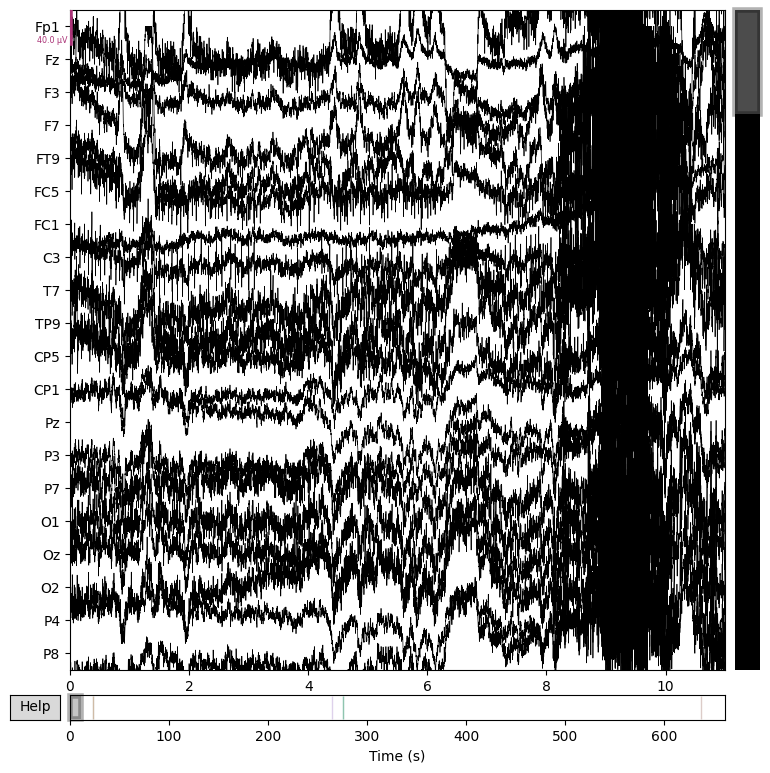

Figure(800x800)


In [119]:
import mne
import pandas as pd

raw = mne.io.read_raw_brainvision(
    "../data/ds004796/sub-01/eeg/sub-01_task-rest_eeg.vhdr",
    preload=True
)

print(raw.info)
print(raw.annotations)
fig = raw.plot(n_channels=20, duration=11)
print(fig)
fig.savefig("../figures/sub-01_rest_raw_eeg.png", dpi=300, bbox_inches="tight")


In [121]:
# Crop the resting-state recording into eyes-open and eyes-closed segments
annotations = raw.annotations
descriptions = list(annotations.description)

eyes_open_start = annotations.onset[descriptions.index("Stimulus/S  2")] # start of eyes open 
eyes_open_end = annotations.onset[descriptions.index("Stimulus/S 10")] # end of eyes open ? 
eyes_closed_start = annotations.onset[descriptions.index("Stimulus/S  4")] # start of eyes closed
eyes_closed_end = annotations.onset[descriptions.index("Stimulus/S 11")] # end of eyes closed ?

raw_eyes_open = raw.copy().crop(tmin=eyes_open_start, tmax=eyes_open_end)
raw_eyes_closed = raw.copy().crop(tmin=eyes_closed_start, tmax=eyes_closed_end)

print(f"Eyes-open segment: {eyes_open_start:.3f}s to {eyes_open_end:.3f}s ({eyes_open_end - eyes_open_start:.1f}s)")
print(f"Eyes-closed segment: {eyes_closed_start:.3f}s to {eyes_closed_end:.3f}s ({eyes_closed_end - eyes_closed_start:.1f}s)")


Eyes-open segment: 23.323s to 264.701s (241.4s)
Eyes-closed segment: 276.067s to 637.358s (361.3s)


Effective window size : 2.048 (s)
Effective window size : 2.048 (s)


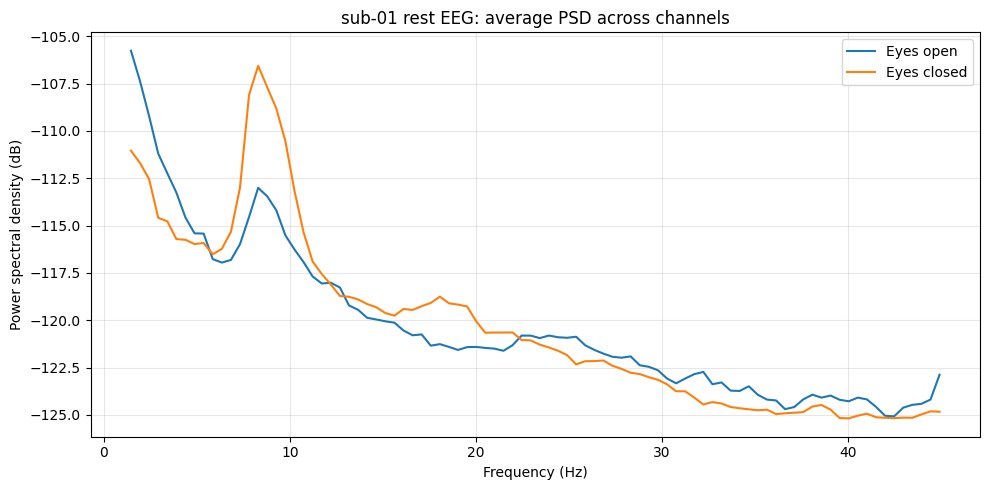

In [122]:
# Compare average PSD for eyes-open vs eyes-closed segments
import matplotlib.pyplot as plt
import numpy as np

psd_open = raw_eyes_open.compute_psd(fmin=1, fmax=45)
psd_closed = raw_eyes_closed.compute_psd(fmin=1, fmax=45)

freqs = psd_open.freqs
open_mean_db = 10 * np.log10(psd_open.get_data().mean(axis=0))
closed_mean_db = 10 * np.log10(psd_closed.get_data().mean(axis=0))

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(freqs, open_mean_db, label="Eyes open")
ax.plot(freqs, closed_mean_db, label="Eyes closed")
ax.set_xlabel("Frequency (Hz)")
ax.set_ylabel("Power spectral density (dB)")
ax.set_title("sub-01 rest EEG: average PSD across channels")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
fig.savefig("../figures/sub-01_rest_psd_open_vs_closed.png", dpi=300, bbox_inches="tight")
plt.show()

Effective window size : 2.048 (s)
Effective window size : 2.048 (s)


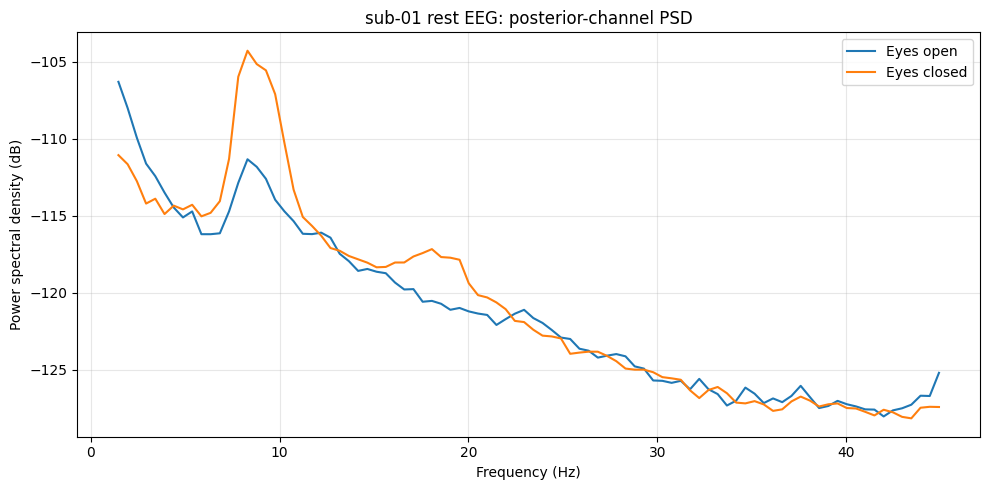

In [123]:
# Compare PSD for posterior channels only, where resting alpha is usually strongest
posterior_channels = ["P3", "Pz", "P4", "O1", "Oz", "O2"]

raw_eyes_open_post = raw_eyes_open.copy().pick(posterior_channels)
raw_eyes_closed_post = raw_eyes_closed.copy().pick(posterior_channels)

psd_open_post = raw_eyes_open_post.compute_psd(fmin=1, fmax=45)
psd_closed_post = raw_eyes_closed_post.compute_psd(fmin=1, fmax=45)

freqs_post = psd_open_post.freqs
open_post_mean_db = 10 * np.log10(psd_open_post.get_data().mean(axis=0))
closed_post_mean_db = 10 * np.log10(psd_closed_post.get_data().mean(axis=0))

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(freqs_post, open_post_mean_db, label="Eyes open")
ax.plot(freqs_post, closed_post_mean_db, label="Eyes closed")
ax.set_xlabel("Frequency (Hz)")
ax.set_ylabel("Power spectral density (dB)")
ax.set_title("sub-01 rest EEG: posterior-channel PSD")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
fig.savefig("../figures/sub-01_rest_psd_posterior_open_vs_closed.png", dpi=300, bbox_inches="tight")
plt.show()